In [1]:
import pandas as pd

df = pd.read_csv("data/processed/videos_features.csv")

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (500, 26)
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_application', 'has_math', 'has_code', 'text_length', 'word_count', 'log_views']


In [2]:
text_columns = [
    "Examples",
    "Analogies",
    "Visuals",
    "Real_Life",
    "Creator_Takeaways"
]

for col in text_columns:
    df[col] = df[col].fillna("").astype(str)

df["example_length"] = df["Examples"].str.len()
df["analogy_length"] = df["Analogies"].str.len()
df["visual_length"] = df["Visuals"].str.len()
df["application_length"] = df["Real_Life"].str.len()
df["takeaway_length"] = df["Creator_Takeaways"].str.len()

df[
    [
        "Title",
        "example_length",
        "analogy_length",
        "visual_length",
        "application_length",
        "takeaway_length"
    ]
].head()

,Title,example_length,analogy_length,visual_length,application_length,takeaway_length
0,But what is a neural network? | Deep learning ...,81,133,129,109,124
1,"Gradient descent, how neural networks learn | ...",63,100,94,77,114
2,A Gentle Introduction to Machine Learning,95,101,106,51,95
3,Machine Learning Fundamentals: Bias and Variance,79,109,82,86,98
4,Machine Learning Fundamentals: Cross Validation,72,88,78,64,94


In [4]:
df.head()


,ID,Category,Channel,Title,URL,Duration,Views,Explanation_Type,Visuals,Examples,...,example_length,analogy_length,visual_length,application_length,takeaway_length,example_suppor,analogy_support,visual_support,practical_support,takeaway_richness
0,VID-001,Machine Learning (ML),3Blue1Brown,But what is a neural network? | Deep learning ...,http://www.youtube.com/watch?v=aircAruvnKk,18:40,24.2M+,Mathematical & Geometric Intuition,Custom Manim animations; dynamic 28x28 pixel g...,MNIST handwritten digit recognition focusing o...,...,81,133,129,109,124,0.284722,0.612403,0.636364,0.776596,0.419847
1,VID-002,Machine Learning (ML),3Blue1Brown,"Gradient descent, how neural networks learn | ...",http://www.youtube.com/watch?v=IHZwWFHWa-w,20:33,9.5M+,Mathematical Optimization & Geometry,3D loss landscape topography; rolling ball phy...,"Minimizing cost over 13,000 weights and biases...",...,63,100,94,77,114,0.159722,0.356589,0.282828,0.436170,0.343511
2,VID-003,Machine Learning (ML),StatQuest with Josh Starmer,A Gentle Introduction to Machine Learning,http://www.youtube.com/watch?v=Gv9_4yMHFhI,12:45,1.6M+,Pedagogical First-Principles Breakdown,Clean 2D scatter plots; color-coded training v...,Predicting love for StatQuest via decision tre...,...,95,101,106,51,95,0.381944,0.364341,0.404040,0.159574,0.198473
3,VID-004,Machine Learning (ML),StatQuest with Josh Starmer,Machine Learning Fundamentals: Bias and Variance,http://www.youtube.com/watch?v=EuBBz3bI-aA,6:36,1.7M+,Visual Error Decomposition,Side-by-side curve fitting comparison; animate...,Mouse weight vs mouse size prediction; straigh...,...,79,109,82,86,98,0.270833,0.426357,0.161616,0.531915,0.221374
4,VID-005,Machine Learning (ML),StatQuest with Josh Starmer,Machine Learning Fundamentals: Cross Validation,http://www.youtube.com/watch?v=fSytzGwwBVw,6:05,1.5M+,Step-by-Step Methodological Walkthrough,Color-coded 10-fold data partition blocks; ani...,Evaluating model fit across patient health met...,...,72,88,78,64,94,0.222222,0.263566,0.121212,0.297872,0.190840


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

support_columns = [
    "example_length",
    "analogy_length",
    "visual_length",
    "application_length",
    "takeaway_length"
]

normalized = scaler.fit_transform(df[support_columns])

df[
    [
        "example_suppor",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
] = normalized

df[
    [
        "Title",
        "example_suppor",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
].head()

,Title,example_suppor,analogy_support,visual_support,practical_support,takeaway_richness
0,But what is a neural network? | Deep learning ...,0.284722,0.612403,0.636364,0.776596,0.419847
1,"Gradient descent, how neural networks learn | ...",0.159722,0.356589,0.282828,0.436170,0.343511
2,A Gentle Introduction to Machine Learning,0.381944,0.364341,0.404040,0.159574,0.198473
3,Machine Learning Fundamentals: Bias and Variance,0.270833,0.426357,0.161616,0.531915,0.221374
4,Machine Learning Fundamentals: Cross Validation,0.222222,0.263566,0.121212,0.297872,0.190840


In [7]:
df["explanation_description_richness"] = df[
    [
        "example_suppor",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
].mean(axis=1)

In [8]:
df[
    [
        "Title",
        "explanation_description_richness"
    ]
].sort_values(
    "explanation_description_richness",
    ascending=False
).head(10)

,Title,explanation_description_richness
480,U-Net clearly explained | Image Segmentation w...,0.763334
481,What is end-to-end deep learning? (C3W2L09),0.743386
378,Advanced RAG 05 - HyDE - Hypothetical Document...,0.687504
377,Advanced RAG: How Corrective RAG (CRAG) Solves...,0.685850
465,C5W3L07 Attention Model Intuition,0.673390
482,Whether to Use End-To-End Deep Learning (C3W2L10),0.669985
374,[GRPO Explained] DeepSeekMath: Pushing the Lim...,0.661501
405,"Geoffrey Hinton: AI, Consciousness, Immortalit...",0.661185
466,C4W4L04 Triplet loss,0.650385
401,SAC | Soft Actor Critic (SAC) architecture | S...,0.646857


In [9]:
coverage_columns = [
    "has_visual",
    "has_example",
    "has_analogy",
    "has_application",
    "has_math",
    "has_code"
]

df["content_coverage"] = (
    df[coverage_columns].sum(axis=1)
    / len(coverage_columns)
)

df[
    [
        "Title",
        "has_visual",
        "has_example",
        "has_analogy",
        "has_application",
        "has_math",
        "has_code",
        "content_coverage"
    ]
].head(10)

,Title,has_visual,has_example,has_analogy,has_application,has_math,has_code,content_coverage
0,But what is a neural network? | Deep learning ...,1,1,1,1,1,0,0.833333
1,"Gradient descent, how neural networks learn | ...",1,1,1,1,1,0,0.833333
2,A Gentle Introduction to Machine Learning,1,1,1,1,0,0,0.666667
3,Machine Learning Fundamentals: Bias and Variance,1,1,1,1,0,0,0.666667
4,Machine Learning Fundamentals: Cross Validation,1,1,1,1,0,0,0.666667
5,Machine Learning Fundamentals: The Confusion M...,1,1,1,1,1,0,0.833333
6,"Decision and Classification Trees, Clearly Exp...",1,1,1,1,1,0,0.833333
7,StatQuest: Logistic Regression,1,1,1,1,1,0,0.833333
8,"StatQuest: Random Forests Part 1 - Building, U...",1,1,1,1,0,0,0.666667
9,StatQuest: K-means clustering,1,1,1,1,0,0,0.666667


In [10]:
technical_terms = (
    r"algorithm|architecture|optimization|gradient|"
    r"equation|mathematical|calculus|probability|"
    r"neural network|transformer|embedding|"
    r"python|pytorch|tensorflow|implementation|code|"
    r"loss function|backpropagation|inference"
)

df["technical_terminology_density"] = df["combined_text"].str.count(
    technical_terms,
    flags=2
)

print(df["technical_terminology_density"].describe())

count    500.000000
mean       2.004000
std        1.927541
min        0.000000
25%        1.000000
50%        1.500000
75%        3.000000
max       13.000000
Name: technical_terminology_density, dtype: float64


In [11]:
max_terms = df["technical_terminology_density"].max()

if max_terms > 0:
    df["technical_depth"] = (
        df["technical_terminology_density"] / max_terms
    )
else:
    df["technical_depth"] = 0

df[
    [
        "Title",
        "technical_terminology_density",
        "technical_depth"
    ]
].sort_values(
    "technical_terminology_density",
    ascending=False
).head(10)

,Title,technical_terminology_density,technical_depth
347,VQ-VAEs: Neural Discrete Representation Learni...,13,1.000000
158,Vision Transformer Quick Guide - Theory and Co...,12,0.923077
124,Residual Networks and Skip Connections (DL 15),9,0.692308
385,DETR: End-to-End Object Detection with Transfo...,9,0.692308
188,LoRA: Low-Rank Adaptation of Large Language Mo...,8,0.615385
415,Sentence Transformers - EXPLAINED!,8,0.615385
484,"DALL·E 2 Explained - model architecture, resul...",8,0.615385
480,U-Net clearly explained | Image Segmentation w...,8,0.615385
238,The spelled-out intro to neural networks and b...,7,0.538462
262,Backpropagation calculus | Deep Learning Chapt...,7,0.538462


In [12]:
coverage_summary = df[coverage_columns].mean().sort_values(
    ascending=False
)

print(coverage_summary)

has_visual         1.000
has_example        1.000
has_analogy        1.000
has_application    1.000
has_math           0.434
has_code           0.210
dtype: float64


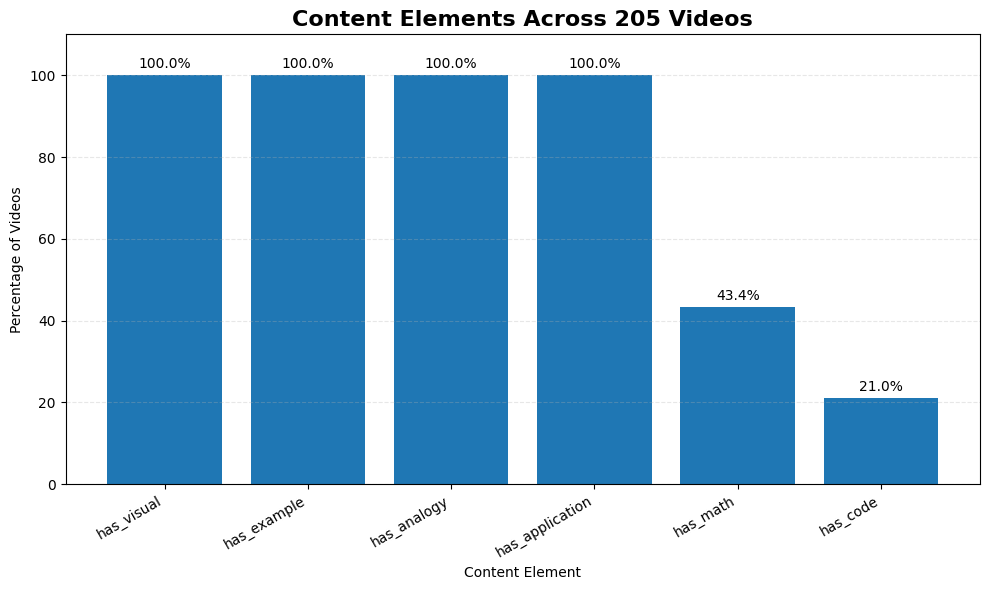

In [13]:
import matplotlib.pyplot as plt
coverage_percent = coverage_summary * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    coverage_percent.index,
    coverage_percent.values
)
for bar, value in zip(bars, coverage_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title(
    "Content Elements Across 205 Videos",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Content Element")
plt.ylabel("Percentage of Videos")

plt.ylim(0, 110)

plt.xticks(rotation=30, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [14]:
df["content_coverage"] = (
    df[coverage_columns].sum(axis=1)
    / len(coverage_columns)
)

In [15]:
df["Explanation_Type"].value_counts()

Explanation_Type
Ultra-Fast Concept Distillation                 2
Visual Diagrammatic Guide                       2
Fast-Paced Motion Graphic Animation             2
Comparative Motion Graphics                     2
Comprehensive Code & Architectural Deep Dive    2
                                               ..
Lightboard Foundational Rationale               1
Rapid Geometric Derivation                      1
Official Curriculum Micro-Animation             1
Lightboard Ensemble Breakdown                   1
Step-by-Step Methodological Walkthrough         1
Name: count, Length: 495, dtype: int64

In [16]:
import numpy as np

embeddings = np.load("data/processed/video_embeddings.npy")

print("Embedding shape:", embeddings.shape)

Embedding shape: (500, 384)


In [17]:
print("Number of videos:", len(df))
print("Number of embeddings:", len(embeddings))

Number of videos: 500
Number of embeddings: 500


In [18]:
from sklearn.preprocessing import normalize

embeddings_normalized = normalize(
    embeddings,
    norm="l2"
)

print("Shape:", embeddings_normalized.shape)

Shape: (500, 384)


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(embeddings_normalized)
    
    score = silhouette_score(
        embeddings_normalized,
        labels
    )
    
    silhouette_scores[k] = score

print("Silhouette Scores:")

for k, score in silhouette_scores.items():
    print(f"K={k}: {score:.4f}")

Silhouette Scores:
K=2: 0.0464
K=3: 0.0465
K=4: 0.0400
K=5: 0.0399
K=6: 0.0442
K=7: 0.0459
K=8: 0.0472
K=9: 0.0521
K=10: 0.0554


In [21]:
final_k = 10

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    embeddings_normalized
)

df["cluster"] = cluster_labels

print(df["cluster"].value_counts().sort_index())

cluster
0    49
1    35
2    64
3    69
4    39
5    34
6    53
7    72
8    44
9    41
Name: count, dtype: int64


In [22]:
for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n===== CLUSTER {cluster_id} =====")
    
    display(
        df[df["cluster"] == cluster_id][
            [
                "Title",
                "Category",
                "Explanation_Type"
            ]
        ].head(10)
    )


===== CLUSTER 0 =====


,Title,Category,Explanation_Type
44,Calculate TF-IDF in NLP (Simple Example),Natural Language Processing (NLP),Manual Calculation & Formula Breakdown
52,Word Embeddings: TF-IDF,Natural Language Processing (NLP),Pragmatic Data Science Tutorial
53,Term Frequency Inverse Document Frequency (TF-...,Natural Language Processing (NLP),Educational Formula Walkthrough
80,What is Retrieval-Augmented Generation (RAG)?,Retrieval-Augmented Generation (RAG),Foundational Lightboard Architecture
81,RAG Explained For Beginners,Retrieval-Augmented Generation (RAG),Step-by-Step Practical Architectural Walkthrough
83,What is a Vector Database? Powering Semantic S...,Retrieval-Augmented Generation (RAG),Core Infrastructure & Math Intuition
84,Vector Databases simply explained! (Embeddings...,Retrieval-Augmented Generation (RAG),Fast-Paced Motion Graphic Animation
85,Every RAG Strategy Explained in 13 Minutes (No...,Retrieval-Augmented Generation (RAG),Strategy Matrix & Architecture Tiers
86,Advanced RAG techniques for developers,Retrieval-Augmented Generation (RAG),Production Best Practices
88,GraphRAG vs. Traditional RAG: Higher Accuracy ...,Retrieval-Augmented Generation (RAG),Emergent Technology Comparison



===== CLUSTER 1 =====


,Title,Category,Explanation_Type
14,Machine Learning | What Is Machine Learning? |...,Machine Learning (ML),Narrative Motion-Graphic Character Storytelling
64,Reinforcement Learning with Human Feedback (RL...,Large Language Models (LLM),Probabilistic Alignment Walkthrough
78,Reinforcement Learning from Human Feedback (RL...,Large Language Models (LLM),Alignment Lightboard Architecture
140,Direct Preference Optimization: Your Language ...,LLM Systems & Inference Optimization,Mathematical Simplification & Paper Breakdown
141,Direct Preference Optimization (DPO) - How to ...,LLM Systems & Inference Optimization,Pedagogical Geometric Intuition
152,Q Learning Explained (tutorial),Reinforcement Learning & Game Theory,High-Energy Interactive Tutorial
153,Deep Q-Networks Explained!,Reinforcement Learning & Game Theory,Neural Network Integration & Stability Tricks
154,Proximal Policy Optimization (PPO) for LLMs Ex...,Reinforcement Learning & Game Theory,Mathematical Pedagogy for AI Practitioners
180,Direct Preference Optimization (DPO) explained...,LLM Systems & Inference Optimization,Rigorous Mathematical Paper Derivation
195,Q-Learning Explained - Reinforcement Learning ...,Reinforcement Learning & Game Theory,Clean Motion Graphics Tutorial



===== CLUSTER 2 =====


...

,Title,Category,Explanation_Type
0,But what is a neural network? | Deep learning ...,Machine Learning (ML),Mathematical & Geometric Intuition
1,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),Mathematical Optimization & Geometry
13,Neural Networks Explained in 5 minutes,Machine Learning (ML),Rapid Architecture Breakdown
16,Essential Machine Learning and AI Concepts Ani...,Machine Learning (ML),Comprehensive Animated Lexicon & Glossary
19,Neural Networks and Deep Learning: Crash Cours...,Machine Learning (ML),Entertaining Cultural & Conceptual Education
20,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),Applied Engineering & Spreadsheet Math
28,Machine Learning Crash Course: Gradient Descent,Machine Learning (ML),Official Curriculum Micro-Animation
63,What is Mixture of Experts?,Large Language Models (LLM),Sparse Architecture & Router Network
117,Variational Autoencoders,Generative AI & Diffusion Models,Intuitive Mathematical Physics & AI Synthesis
120,Graph Neural Networks - a perspective from the...,Advanced Neural Architectures,Foundational Graph Theory & Message Passing



===== CLUSTER 8 =====


,Title,Category,Explanation_Type
2,A Gentle Introduction to Machine Learning,Machine Learning (ML),Pedagogical First-Principles Breakdown
3,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),Visual Error Decomposition
4,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),Step-by-Step Methodological Walkthrough
5,Machine Learning Fundamentals: The Confusion M...,Machine Learning (ML),Analytical Metric Derivation
6,"Decision and Classification Trees, Clearly Exp...",Machine Learning (ML),Hierarchical Logic & Splitting Math
7,StatQuest: Logistic Regression,Machine Learning (ML),Probabilistic Curve Fitting
8,"StatQuest: Random Forests Part 1 - Building, U...",Machine Learning (ML),Ensemble Learning & Bagging
10,Machine Learning Explained in 100 Seconds,Machine Learning (ML),High-Velocity Developer Micro-Overview
12,Supervised vs. Unsupervised Learning,Machine Learning (ML),Taxonomic Comparison & Structural Contrast
15,Machine Learning for Everybody – Full Course,Machine Learning (ML),Comprehensive Hands-on Code-Along Tutorial



===== CLUSTER 9 =====


,Title,Category,Explanation_Type
56,[1hr Talk] Intro to Large Language Models,Large Language Models (LLM),Masterclass Systems Engineering
61,Optimize Your AI - Quantization Explained,Large Language Models (LLM),Hardware & Model Compression Breakdown
65,How KV Cache Speeds Up LLMs for Faster AI Mode...,Large Language Models (LLM),Inference Optimization & Memory Footprint
75,How LLMs survive in low precision | Quantizati...,Large Language Models (LLM),Hardware & Mathematical Engineering
79,The KV Cache: Memory Usage in Transformers,Large Language Models (LLM),GPU Systems Deep Dive
122,MAMBA and State Space Models explained | SSM e...,Advanced Neural Architectures,Theoretical Deep-Dive & Hardware-Aware Algorithms
123,Intuition behind Mamba and State Space Models ...,Advanced Neural Architectures,Visual Diagrammatic Guide
133,Model Context Protocol Clearly Explained | MCP...,Agentic AI & Multi-Agent Systems,Industry Strategic Analysis
142,How FlashAttention Accelerates Generative AI R...,LLM Systems & Inference Optimization,GPU Architecture & Hardware Tiling
144,What is vLLM? Efficient AI Inference for Large...,LLM Systems & Inference Optimization,Systems Infrastructure & PagedAttention


In [23]:
cluster_category = pd.crosstab(
    df["cluster"],
    df["Category"]
)

cluster_category

Category,"3D AI, Gaussian Splatting & World Models","AI History, Big Tech & Pioneer Dialogues",AI Safety & Mechanistic Interpretability,Academic Lectures & Foundational Courses,Advanced Neural Architectures,Advanced Retrieval & Search,Agentic AI & Multi-Agent Systems,Biomolecular & Scientific AI,Computer Vision & Multimodal AI,Deep Learning Fundamentals,...,Machine Learning (ML),Mathematics for Machine Learning,Natural Language Processing (NLP),"Quantization, Distillation & Model Compression",Reasoning Models & Test-Time Compute,Reinforcement Learning & AI Milestones,Reinforcement Learning & Game Theory,Retrieval-Augmented Generation (RAG),Robotics & Vision-Language-Action (VLA),Vector Search & Graph RAG
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,17,0,0,0,0,...,0,0,4,0,0,0,0,25,0,2
1,1,2,1,1,0,0,0,0,0,0,...,1,0,0,1,2,2,14,0,2,0
2,0,4,2,0,0,1,30,0,0,0,...,0,0,1,0,1,1,0,3,1,1
3,0,0,1,11,1,0,0,0,7,0,...,3,1,25,0,3,0,0,0,2,0
4,0,2,0,1,0,0,0,2,0,0,...,15,18,0,0,0,0,0,0,0,0
5,1,0,0,2,0,0,0,0,3,0,...,0,1,0,0,0,0,0,0,0,0
6,3,0,0,10,5,0,0,0,21,7,...,3,2,0,0,0,0,0,0,1,0
7,0,4,4,13,7,0,1,0,0,13,...,13,5,2,1,1,0,1,0,0,0
8,0,0,0,6,0,0,0,0,0,0,...,31,6,0,0,0,0,0,0,0,0


In [24]:
cluster_category_percentage = pd.crosstab(
    df["cluster"],
    df["Category"],
    normalize="index"
) * 100

cluster_category_percentage.round(1)

Category,"3D AI, Gaussian Splatting & World Models","AI History, Big Tech & Pioneer Dialogues",AI Safety & Mechanistic Interpretability,Academic Lectures & Foundational Courses,Advanced Neural Architectures,Advanced Retrieval & Search,Agentic AI & Multi-Agent Systems,Biomolecular & Scientific AI,Computer Vision & Multimodal AI,Deep Learning Fundamentals,...,Machine Learning (ML),Mathematics for Machine Learning,Natural Language Processing (NLP),"Quantization, Distillation & Model Compression",Reasoning Models & Test-Time Compute,Reinforcement Learning & AI Milestones,Reinforcement Learning & Game Theory,Retrieval-Augmented Generation (RAG),Robotics & Vision-Language-Action (VLA),Vector Search & Graph RAG
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,34.7,0.0,0.0,0.0,0.0,...,0.0,0.0,8.2,0.0,0.0,0.0,0.0,51.0,0.0,4.1
1,2.9,5.7,2.9,2.9,0.0,0.0,0.0,0.0,0.0,0.0,...,2.9,0.0,0.0,2.9,5.7,5.7,40.0,0.0,5.7,0.0
2,0.0,6.2,3.1,0.0,0.0,1.6,46.9,0.0,0.0,0.0,...,0.0,0.0,1.6,0.0,1.6,1.6,0.0,4.7,1.6,1.6
3,0.0,0.0,1.4,15.9,1.4,0.0,0.0,0.0,10.1,0.0,...,4.3,1.4,36.2,0.0,4.3,0.0,0.0,0.0,2.9,0.0
4,0.0,5.1,0.0,2.6,0.0,0.0,0.0,5.1,0.0,0.0,...,38.5,46.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.9,0.0,0.0,5.9,0.0,0.0,0.0,0.0,8.8,0.0,...,0.0,2.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,5.7,0.0,0.0,18.9,9.4,0.0,0.0,0.0,39.6,13.2,...,5.7,3.8,0.0,0.0,0.0,0.0,0.0,0.0,1.9,0.0
7,0.0,5.6,5.6,18.1,9.7,0.0,1.4,0.0,0.0,18.1,...,18.1,6.9,2.8,1.4,1.4,0.0,1.4,0.0,0.0,0.0
8,0.0,0.0,0.0,13.6,0.0,0.0,0.0,0.0,0.0,0.0,...,70.5,13.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    df["Category"],
    df["cluster"]
)

nmi = normalized_mutual_info_score(
    df["Category"],
    df["cluster"]
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.2647
Normalized Mutual Information (NMI): 0.4886


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(
    embeddings_normalized
)

print("Original shape:", embeddings_normalized.shape)
print("Reduced shape:", embeddings_2d.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original shape: (500, 384)
Reduced shape: (500, 2)
Explained variance: [0.0669761  0.04690257]
Total explained variance: 0.11387867


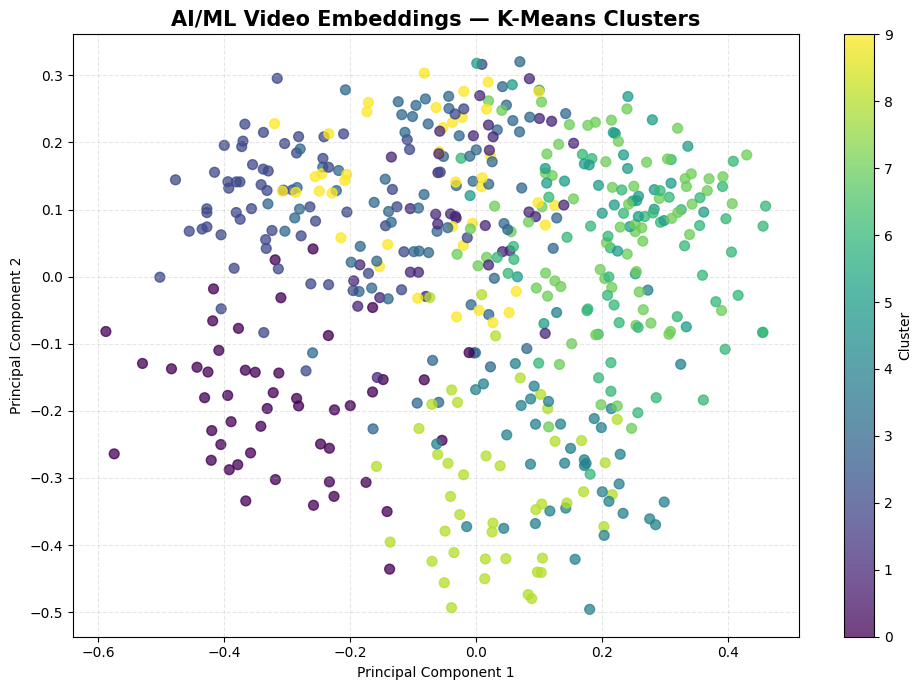

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster"],
    s=50,
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "AI/ML Video Embeddings — K-Means Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

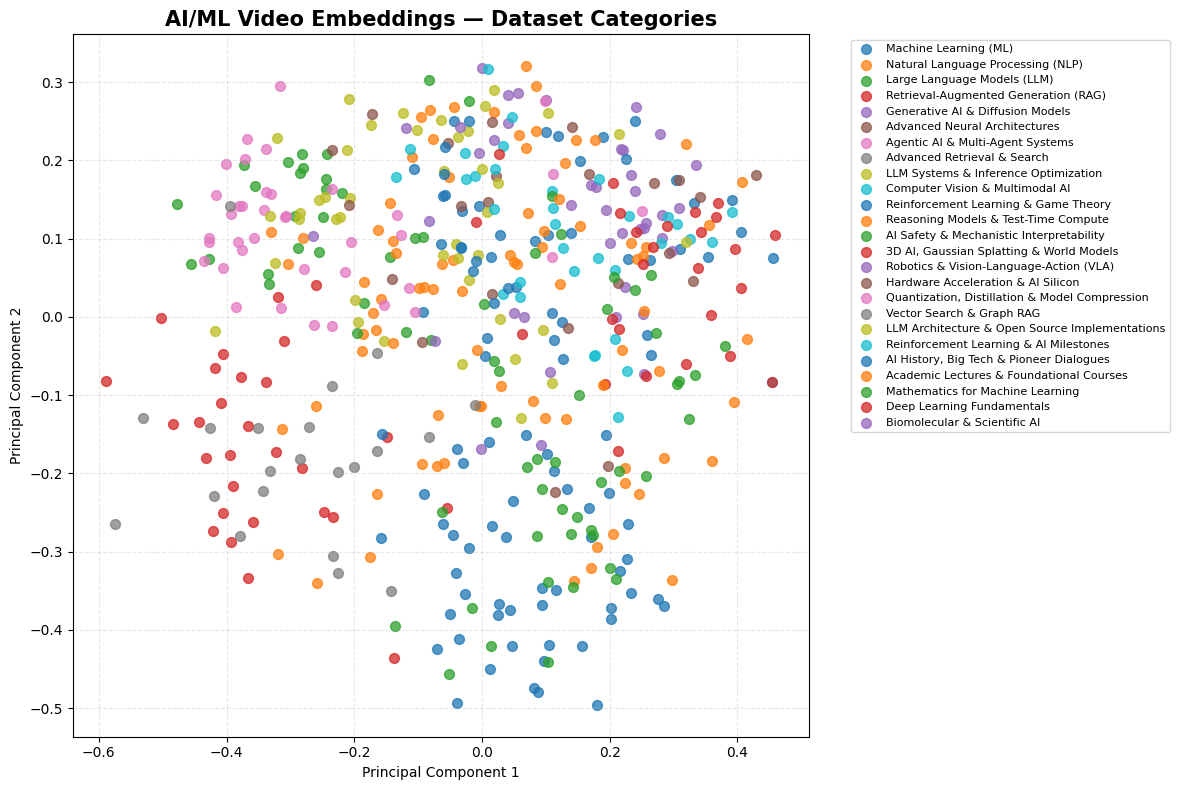

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

categories = df["Category"].unique()

for category in categories:
    mask = df["Category"] == category
    
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=50,
        alpha=0.75,
        label=category
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "AI/ML Video Embeddings — Dataset Categories",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [29]:
df.to_csv(
    "data/processed/videos_clustered.csv",
    index=False
)

print("Saved:", df.shape)

Saved: (500, 41)


In [30]:
np.save(
    "data/processed/video_embeddings_normalized.npy",
    embeddings_normalized
)

print("Normalized embeddings saved.")

Normalized embeddings saved.
